## Imports

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [2]:
pyfers_path = os.path.abspath('..')

if pyfers_path not in sys.path:
    sys.path.append(pyfers_path)

import pyfers as fers

## Radar Parameters

In [3]:
chirp = fers.Waveform(name='Chirp', f_carrier=9e6, type='pulse', power=20, f_sample=150e6, bandwidth=100e6, t_pulse=2e-6)
antenna = fers.Antenna(name='Antenna', type='sinc', gain=2, efficiency=1, az_beta=20, el_beta=5, az_gamma=2, el_gamma=2)
clock = fers.Clock(name='Clock', frequency=150e6)
transmitter = fers.Transmitter(name='Transmitter', antenna=antenna, waveform=chirp, clock=clock, f_prf=1000)
receiver = fers.Receiver(name='Receiver', antenna=antenna, clock=clock, f_prf=1000, gate=1000, noise_temp=100)

### Axes

In [4]:
r_gate = np.linspace(0, receiver.gate, receiver.ns_gate, endpoint=False)
t_gate = fers.range_to_time(r_gate)

## Simulation Parameters

In [5]:
n_seconds = 10
adc_bits = 16
adc_rate = 150e6

n_pulses = int(transmitter.f_prf * n_seconds)

### TX Waveform

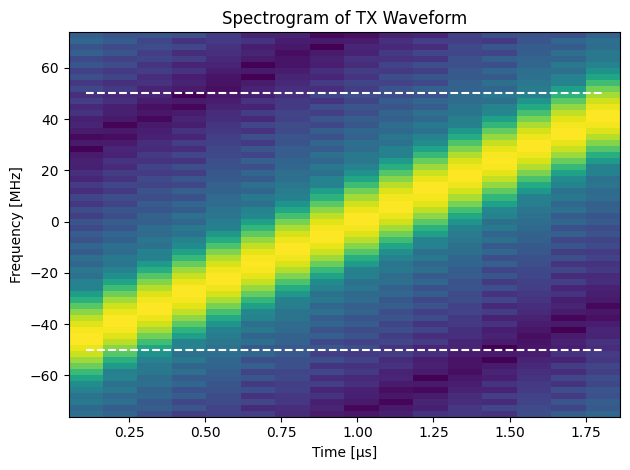

In [6]:
f, t, spect = signal.spectrogram(
    chirp.samples,
    fs=adc_rate,
    nperseg=32,
    nfft=64,
    noverlap=15,
    mode='magnitude',
    window='blackman',
    return_onesided=False,
    detrend=False
)

spect = fers.linear_to_dB(np.abs(spect))
spect -= spect.max()

spect = np.fft.fftshift(spect, axes=0)
t *= 1e6
f = np.fft.fftshift(f)/1e6

plt.figure()
plt.hlines(chirp.bandwidth/2e6, t[0], t[-1], linestyles='--', colors='white')
plt.hlines(-chirp.bandwidth/2e6, t[0], t[-1], linestyles='--', colors='white')
plt.pcolormesh(t, f, spect)
plt.title('Spectrogram of TX Waveform')
plt.xlabel('Time [µs]')
plt.ylabel('Frequency [MHz]')
plt.tight_layout()

### Antenna Beam Pattern

Antenna Gain: 1.99 dBi


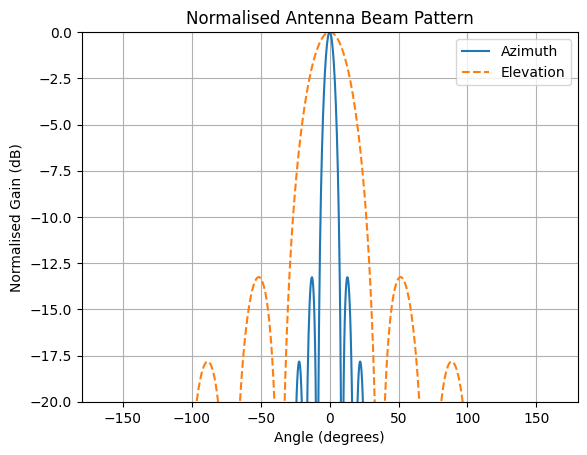

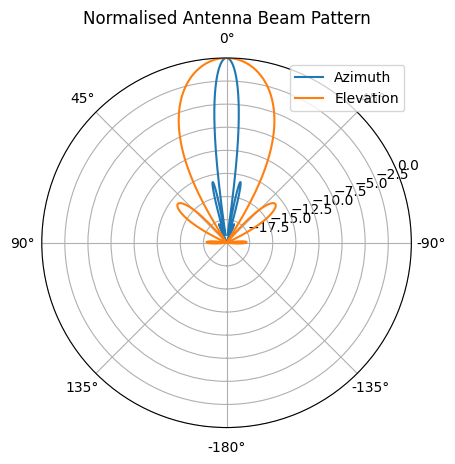

In [7]:
# convert to dBi
G_az_dBi = 10*np.log10(abs(antenna.az_pattern) + 1e-20)
G_el_dBi = 10*np.log10(abs(antenna.el_pattern) + 1e-20)

# calculate the peak gain
assert round(np.max(G_az_dBi), 1) == round(np.max(G_el_dBi), 1)
G_dBi = np.max(G_az_dBi)
print('Antenna Gain:', round(G_dBi, 2), 'dBi')

# normalise the beam pattern
G_az_dBi -= G_dBi
G_el_dBi -= G_dBi

plt.figure()
plt.title("Normalised Antenna Beam Pattern")
plt.plot(np.degrees(antenna.theta), G_az_dBi, label="Azimuth")
plt.plot(np.degrees(antenna.theta), G_el_dBi, label="Elevation", linestyle="--")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalised Gain (dB)")
plt.ylim(-20, 0)
plt.xlim(-180, 180)
plt.legend()
plt.grid()

plt.figure()
ax = plt.subplot(1, 1, 1, projection='polar')
ax.set_title('Normalised Antenna Beam Pattern')
ax.plot(antenna.theta, G_az_dBi, label="Azimuth")
ax.plot(antenna.theta, G_el_dBi, label="Elevation")
ax.set_theta_zero_location('N')
ax.set_ylim(-20, 0)
ax.set_xlim(-np.pi, np.pi)
ax.set_rlabel_position(292.5)
ax.grid(True)
ax.legend()

## Platform Parameters
- Along-Track (m):    x-axis
- Cross-Track (m):    y-axis
- Altitude (m):       z-axis
- Azimuth (deg):      x-y plane
- Elevation (deg):    x-z plane

### Ideal Motion

In [8]:
velocity = 50
altitude = 300
depression = -30
squint = 0

aircraft = fers.DynamicPlatform(name='Aircraft', d=n_seconds, fs=10)
aircraft.add_motion('linear', 'x', gradient=velocity)
aircraft.add_motion('constant', 'y', constant=0)
aircraft.add_motion('constant', 'z', constant=altitude)
aircraft.add_motion('constant', 'az', constant=squint)
aircraft.add_motion('constant', 'el', constant=depression)

### Simulated Non-Ideal Motion

In [9]:
# # along-track noise
# aircraft.add_motion('sinusoid', 'x', amplitude=1, frequency=1.6/n_seconds, phase=0)

# # cross-track noise
# aircraft.add_motion('sinusoid', 'y', amplitude=10, frequency=1.3/n_seconds, phase=np.pi/4)
# aircraft.add_motion('sinusoid', 'y', amplitude=0.2, frequency=5.5/n_seconds, phase=0)

# # altitude noise
# aircraft.add_motion('sinusoid', 'z', amplitude=15, frequency=0.75/n_seconds, phase=3*np.pi/4)
# aircraft.add_motion('sinusoid', 'z', amplitude=1, frequency=3.2/n_seconds, phase=np.pi/4)

# # azimuth noise
# aircraft.add_motion('sinusoid', 'az', amplitude=1, frequency=2.3/n_seconds, phase=5*np.pi/8)
# aircraft.add_motion('sinusoid', 'az', amplitude=0.7, frequency=1.1/n_seconds, phase=np.pi/8)

# # elevation noise
# aircraft.add_motion('sinusoid', 'el', amplitude=2, frequency=2.7/n_seconds, phase=3*np.pi/8)

### Visualise Platform Motion

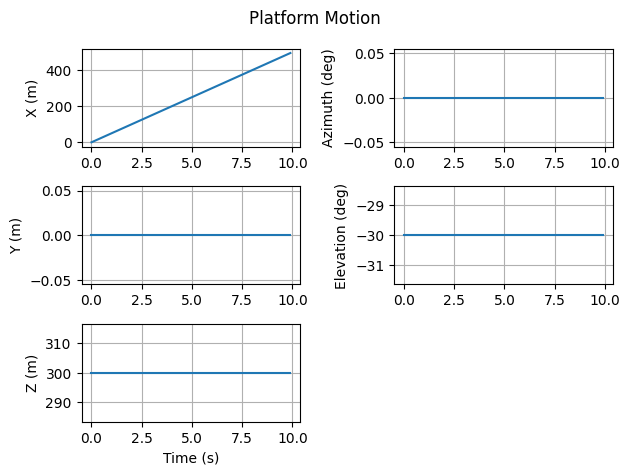

In [10]:
plt.figure()
plt.suptitle("Platform Motion")

plt.subplot(321)
plt.plot(aircraft.t, aircraft.x)
plt.ylabel('X (m)')
plt.grid()

plt.subplot(322)
plt.plot(aircraft.t, aircraft.az)
plt.ylabel('Azimuth (deg)')
plt.grid()

plt.subplot(323)
plt.plot(aircraft.t, aircraft.y)
plt.ylabel('Y (m)')
plt.grid()

plt.subplot(324)
plt.plot(aircraft.t, aircraft.el)
plt.ylabel('Elevation (deg)')
plt.grid()

plt.subplot(325)
plt.plot(aircraft.t, aircraft.z)
plt.ylabel("Z (m)")
plt.xlabel('Time (s)')
plt.grid()

plt.tight_layout()

## Targets

In [11]:
targets = [
    fers.Target('Target A', rcs=100, platform=fers.StaticPlatform(name='Platform A', x=250, y=400)),
    # fers.Target('Target B', rcs=300, platform=fers.StaticPlatform(name='Platform B', x=150, y=600)),
    # fers.Target('Target C', rcs=100, platform=fers.StaticPlatform(name='Platform C', x=350, y=200))
]

## Visualise Scene

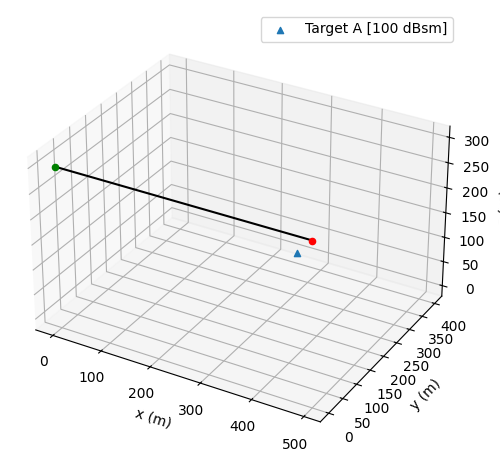

In [12]:
plt.figure()
ax = plt.axes(projection='3d')

# aircraft path
ax.plot3D(aircraft.x, aircraft.y, aircraft.z, color='black')
ax.scatter3D(aircraft.x[0], aircraft.y[0], aircraft.z[0], marker='o', color='green')
ax.scatter3D(aircraft.x[-1], aircraft.y[-1], aircraft.z[-1], marker='o', color='red')

# targets
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, target in enumerate(targets):
    ax.scatter3D(
        target.platform.x,
        target.platform.y,
        target.platform.z,
        marker='^',
        color=cycle[i],
        label=(target.name + ' [' + str(target.rcs) + ' dBsm]')
    )

# ax.set_title('FERS Simulation Scene')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.legend()
ax.set_aspect('equal')
# ax.view_init(elev=45, azim=-45)
# ax.view_init(elev=270, azim=180)
plt.tight_layout()

## FERS

In [13]:
sim = fers.Simulation(name='demo', filename="demo.fersxml")

# TODO tidy this up
sim.add_parameters(t_start=0, t_end=(n_seconds-transmitter.t_pri), sim_rate=adc_rate, bits=adc_bits)

sim.add_waveform(chirp, "waveform.h5")
sim.add_clock(clock)
sim.add_antenna(antenna, "antenna.xml")
sim.add_monostatic(aircraft, transmitter, receiver, antenna, chirp, clock)
# sim.add_transmitter(fers.StaticPlatform(name='TX Platform', x=0), transmitter, antenna, chirp, clock)
# sim.add_receiver(fers.StaticPlatform(name='RX Platform', x=2), receiver, antenna, clock)
for t in targets:
    sim.add_target(t)

sim.write_xml()
sim.run()

[2026-03-26 18:24:52] [INFO   ] [api.cpp:140                   ] FERS CLI started. Using libfers backend.
[2026-03-26 18:24:52] [INFO   ] [api.cpp:140                   ] Loading scenario from '/Users/darryn/git/pyfers/test/demo.fersxml'...
[2026-03-26 18:24:52] [INFO   ] [xml_parser_utils.cpp:969      ] Simulation name set to: demo
[2026-03-26 18:24:52] [INFO   ] [xml_parser_utils.cpp:119      ] Simulation time set from 0.00000 to 9.99900 seconds
[2026-03-26 18:24:52] [INFO   ] [xml_parser_utils.cpp:153      ] Propagation speed (c) set to: 299792458.00000
[2026-03-26 18:24:52] [WARNING] [xml_parser_utils.cpp:145      ] Failed to set parameter simSamplingRate. Using default value. 1000
[2026-03-26 18:24:52] [INFO   ] [timing.cpp:56                 ] Timing source 'Clock': applying random frequency offset with stdev 0 Hz.
[2026-03-26 18:24:52] [INFO   ] [timing.cpp:64                 ] Timing source 'Clock': applying random phase offset with stdev 0 radians.
[2026-03-26 18:24:52] [INFO 

## Received Data

In [14]:
rx_matrix = fers.read_hdf5(receiver.name + "_results.h5")

# check the dimensions of the received data
assert np.shape(rx_matrix) == (n_pulses, receiver.ns_gate)

### Intensity

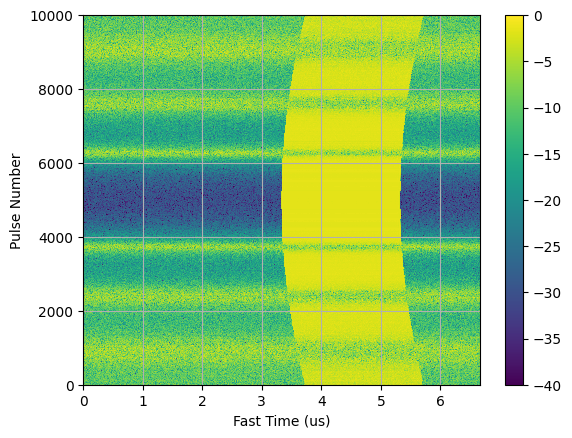

In [15]:
to_plot = fers.linear_to_dB(abs(rx_matrix) + 1e-20)
to_plot -= np.max(to_plot)

plt.imshow(
    to_plot,
    aspect='auto',
    vmax=0,
    vmin=-40,
    interpolation='none',
    extent=[0, t_gate[-1]*1e6, 0, n_pulses],
)
plt.colorbar()
plt.xlabel('Fast Time (us)')
plt.ylabel('Pulse Number')
plt.grid()

### Phase

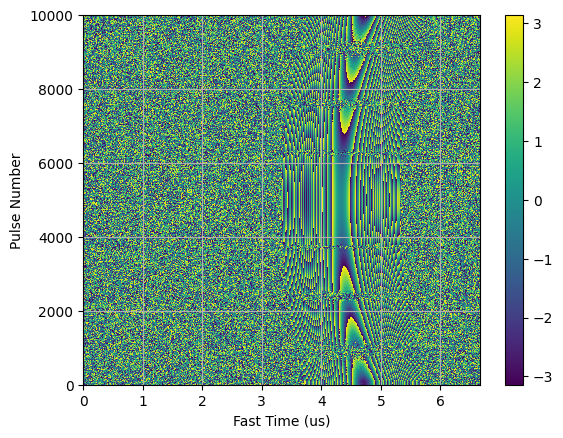

In [16]:
plt.imshow(
    np.angle(rx_matrix),
    aspect='auto',
    interpolation='none',
    extent=[0, t_gate[-1]*1e6, 0, n_pulses],
)
plt.colorbar()
plt.xlabel('Fast Time (us)')
plt.ylabel('Pulse Number')
plt.grid()

### Noise Power Bug
FERS appears to vary the noise power level based on the power of the received signal i.e., if there is a strong target present the noise power before and after the signal appears to reduce. If there is a null in the radiation pattern the noise power increases. The peaks in the following plot correspond to regions of increased noise power in the notches of the sinc antenna pattern.

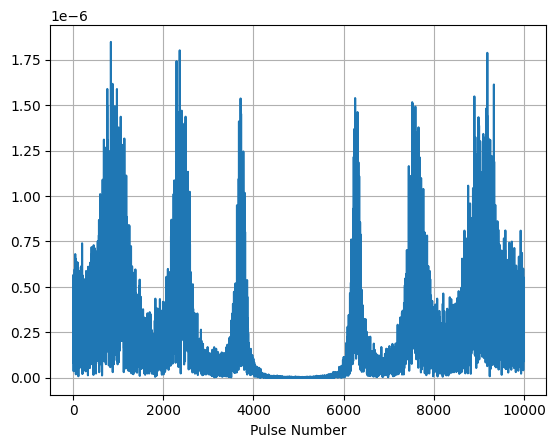

In [17]:
plt.figure()
plt.plot(abs(rx_matrix[:, 0]))
plt.xlabel('Pulse Number')
plt.grid()

# TODO check this!
# print('Predicted Noise Density:', np.round(fers.linear_to_dB(receiver.noise_density) + 30, 2), '[dBm/Hz]')
# print('Measured Noise Density:', round(np.mean(2*fers.linear_to_dB(abs(rx_matrix))) + 30 - fers.linear_to_dB(150e6), 2), 'dBm/Hz')